Nama   : Megan Febriana Putri Johana

NIM    : A11.2023.15039

Kelas  : BENGEKELCODING-DS01

Link Repo : https://github.com/meganfbr/UAS_BENGKOD.git

# Ujian Akhir Semester
## Prediksi Customer Churn Menggunakan Machine Learning

Dataset yang digunakan adalah Sales and Marketing Customer Dataset yang berisi informasi pelanggan, aktivitas penggunaan layanan, transaksi, dan interaksi pelanggan. Tujuan penelitian ini adalah membangun model machine learning untuk memprediksi apakah pelanggan akan melakukan churn atau tidak.

## Load Dataset

Tahap ini bertujuan untuk memuat dataset Sales and Marketing Customer Dataset ke dalam lingkungan Google Colab. Dataset kemudian disimpan dalam DataFrame pandas untuk proses eksplorasi data dan pemodelan machine learning.

In [169]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [170]:
sales_path = "/content/drive/MyDrive/BENGKOD_MEGAN FPJ/UAS_BENGKOD/Sales - Marketing customer dataset.csv"

### Menampilkan 5 Baris Pertama Dataset

Lima baris pertama dataset ditampilkan untuk memahami struktur data, jenis fitur yang tersedia, serta mengidentifikasi adanya nilai kosong atau anomali awal pada data.

In [171]:
import pandas as pd

df = pd.read_csv(sales_path)
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


Pada tahap ini dilakukan import library yang dibutuhkan dalam proses analisis data dan pemodelan machine learning.

Library pandas digunakan untuk membaca, mengolah, dan memanipulasi dataset dalam bentuk DataFrame. Library numpy digunakan untuk operasi numerik dan perhitungan array. Library matplotlib.pyplot dan seaborn digunakan untuk membuat visualisasi data, seperti diagram batang, heatmap, dan grafik distribusi. Selain itu, library warnings digunakan untuk menyembunyikan pesan peringatan agar output notebook lebih rapi dan mudah dibaca.

In [172]:
#Untuk membaca dan mengolah data tabel, misalnya CSV menjadi DataFrame.
import pandas as pd
#Untuk operasi numerik, array, dan perhitungan matematika.
import numpy as np
#Untuk membuat grafik dasar seperti bar chart, line chart, dan boxplot.
import matplotlib.pyplot as plt
#Untuk visualisasi data yang lebih rapi, seperti countplot dan heatmap.
import seaborn as sns
#Untuk mengabaikan warning agar tampilan output Colab tidak terlalu penuh.
import warnings
warnings.filterwarnings("ignore")

In [173]:
from google.colab import drive
drive.mount('/content/drive')

sales_path = "/content/drive/MyDrive/BENGKOD_MEGAN FPJ/UAS_BENGKOD/Sales - Marketing customer dataset.csv"

df = pd.read_csv(sales_path)

print("Jumlah baris dan kolom:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Jumlah baris dan kolom: (15000, 30)


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


## Informasi Dataset

Tahap ini dilakukan untuk mengetahui struktur dataset, jumlah baris dan kolom, tipe data setiap fitur, serta keberadaan nilai kosong (missing value). Informasi ini penting sebagai dasar dalam menentukan langkah preprocessing yang akan dilakukan sebelum proses pemodelan machine learning.

Berdasarkan hasil `df.info()`, dataset terdiri dari 15.000 baris data dan 30 kolom yang mencakup 10 fitur numerik bertipe `float64`, 10 fitur numerik bertipe `int64`, dan 10 fitur kategorikal bertipe `object`. Beberapa kolom masih memiliki nilai kosong (missing value), yaitu `gender`, `age`, `total_spent`, `coupon_code`, dan `satisfaction_score`. Kolom `coupon_code` memiliki jumlah missing value paling banyak dibandingkan kolom lainnya.

Selain itu, terdapat dua fitur bertipe tanggal yaitu `signup_date` dan `last_purchase_date` yang masih terbaca sebagai `object` sehingga memerlukan penyesuaian pada tahap preprocessing. Informasi ini menunjukkan bahwa dataset memerlukan penanganan missing value serta transformasi data sebelum digunakan dalam proses pelatihan model machine learning.


In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

## Statistik Deskriptif Fitur Kategorikal

Tahap ini dilakukan untuk melihat ringkasan statistik pada fitur kategorikal. Informasi yang ditampilkan meliputi jumlah data yang tersedia (count), jumlah kategori unik (unique), kategori yang paling sering muncul (top), serta frekuensi kemunculannya (freq). Analisis ini membantu memahami karakteristik data kategorikal sebelum dilakukan proses encoding.


Berdasarkan hasil statistik deskriptif fitur kategorikal, diketahui bahwa dataset memiliki beberapa fitur kategorikal seperti `gender`, `country`, `city`, `acquisition_channel`, `device_type`, `subscription_type`, `coupon_code`, dan `payment_method`.

Fitur `country` terdiri dari 5 kategori negara, sedangkan `city` terdiri dari 7 kategori kota. Pada fitur `gender`, kategori yang paling banyak muncul adalah **Male** sebanyak 6.844 data. Untuk fitur `acquisition_channel`, sumber pelanggan yang paling dominan adalah **Organic** dengan frekuensi 3.055 data. Selain itu, jenis perangkat yang paling sering digunakan adalah **Tablet** sebanyak 5.043 data, sedangkan tipe langganan yang paling banyak digunakan adalah **Monthly** sebanyak 7.666 data.

Hasil analisis ini menunjukkan bahwa sebagian besar pelanggan menggunakan langganan bulanan dan berasal dari kanal akuisisi organik. Informasi tersebut dapat menjadi indikator penting yang berpotensi mempengaruhi perilaku churn pelanggan dan akan digunakan pada tahap pemodelan setelah dilakukan proses encoding.


---



In [175]:
df.describe(include="object")

,gender,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,coupon_code,payment_method
count,14262,15000,15000,15000,15000,15000,15000,15000,8867,15000
unique,3,5,7,1000,800,5,3,2,3,5
top,Male,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,REF10,UPI
freq,6844,3072,2236,29,32,3055,5043,7666,2995,3105


## Analisis Missing Value

Tahap ini dilakukan untuk mengidentifikasi jumlah dan persentase data yang hilang (missing value) pada setiap kolom dalam dataset. Informasi ini digunakan sebagai dasar dalam menentukan metode penanganan missing value pada tahap preprocessing sehingga kualitas data dapat ditingkatkan sebelum proses pemodelan dilakukan.

In [176]:
missing_percent = df.isnull().mean() * 100

#Mengurutkan kolom berdasarkan persentase missing value dari yang terbesar ke yang terkecil.
missing_percent = missing_percent.sort_values(ascending=False)
#Menampilkan hasil persentase missing value setiap kolom.
missing_percent

,0
coupon_code,40.886667
age,8.000000
total_spent,7.000000
gender,4.920000
satisfaction_score,4.680000
customer_id,0.000000
last_purchase_date,0.000000
acquisition_channel,0.000000
device_type,0.000000
subscription_type,0.000000


missing_percent = df.isnull().mean() * 100

Menghitung persentase missing value pada setiap kolom.

Penjelasan:

* isnull() → mendeteksi nilai kosong (NaN)
* mean() → menghitung proporsi nilai kosong
* 100 → mengubah menjadi persentase

Berdasarkan hasil analisis missing value, diketahui bahwa sebagian besar fitur pada dataset tidak memiliki nilai kosong. Namun terdapat beberapa kolom yang masih mengandung missing value, yaitu `coupon_code` sebesar 40,89%, `age` sebesar 8,00%, `total_spent` sebesar 7,00%, `gender` sebesar 4,92%, dan `satisfaction_score` sebesar 4,68%.

Kolom `coupon_code` memiliki persentase missing value tertinggi karena tidak semua pelanggan menggunakan kupon saat melakukan transaksi. Sementara itu, missing value pada kolom `age`, `total_spent`, `gender`, dan `satisfaction_score` masih berada pada tingkat yang relatif rendah sehingga dapat ditangani pada tahap preprocessing menggunakan teknik imputasi.

Hasil analisis ini menunjukkan bahwa dataset masih layak digunakan untuk pemodelan machine learning setelah dilakukan penanganan missing value yang sesuai.


## Visualisasi Missing Value

Visualisasi missing value dilakukan untuk memberikan gambaran yang lebih jelas mengenai distribusi nilai kosong pada setiap kolom. Diagram batang digunakan untuk mempermudah identifikasi fitur yang memiliki persentase missing value tertinggi sehingga dapat menjadi prioritas dalam tahap preprocessing.

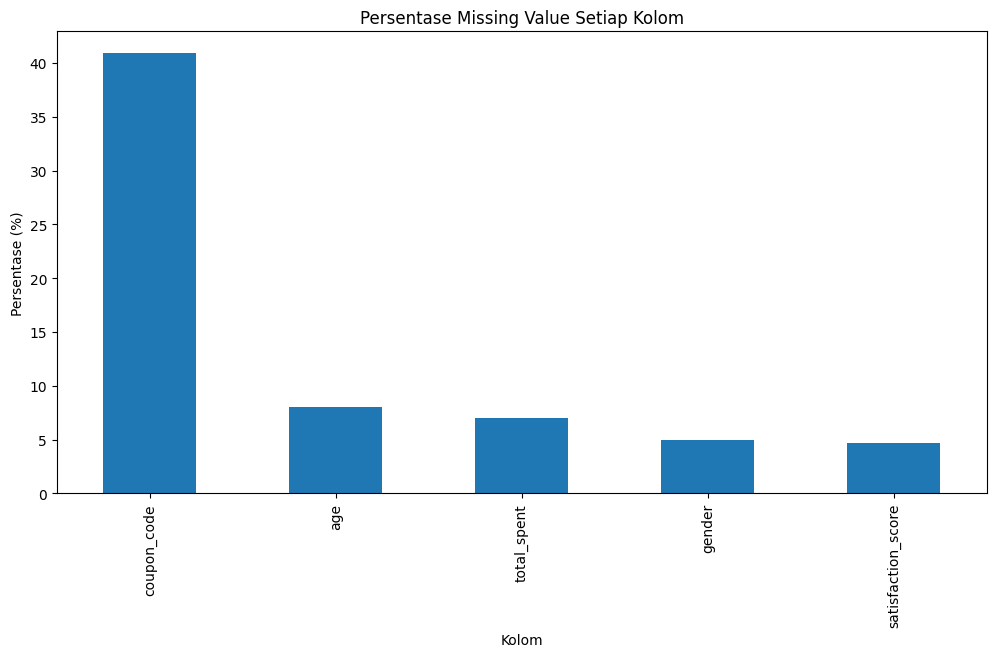

In [177]:
#Mengatur ukuran grafik menjadi lebar 12 dan tinggi 6
plt.figure(figsize=(12, 6))
#Menampilkan diagram batang hanya untuk kolom yang memiliki missing value lebih dari 0%
missing_percent[missing_percent > 0].plot(kind="bar")
#Memberikan judul grafik
plt.title("Persentase Missing Value Setiap Kolom")
#Memberikan label sumbu Y
plt.ylabel("Persentase (%)")
#Memberikan label sumbu X
plt.xlabel("Kolom")
#Memutar nama kolom agar tidak bertumpuk
plt.xticks(rotation=90)
#Menampilkan grafik
plt.show()

Berdasarkan diagram batang missing value, terlihat bahwa kolom `coupon_code` memiliki persentase nilai kosong paling tinggi yaitu sekitar 40,89%. Kondisi ini menunjukkan bahwa sebagian besar pelanggan tidak menggunakan kupon saat melakukan transaksi. Selain itu, terdapat beberapa kolom lain yang memiliki missing value dengan persentase relatif rendah, yaitu `age` sebesar 8%, `total_spent` sebesar 7%, `gender` sebesar 4,92%, dan `satisfaction_score` sebesar 4,68%.

Secara umum, sebagian besar fitur dalam dataset tidak memiliki missing value sehingga kualitas data dapat dikategorikan cukup baik. Missing value yang ditemukan akan ditangani pada tahap preprocessing menggunakan metode imputasi yang sesuai berdasarkan tipe data masing-masing fitur.


## Analisis Data Duplikat

Tahap ini dilakukan untuk memeriksa apakah terdapat baris data yang identik (duplikat) dalam dataset. Data duplikat dapat menyebabkan bias pada proses pelatihan model sehingga perlu diidentifikasi sebelum dilakukan pemodelan.

In [178]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


Hasil pemeriksaan menunjukkan bahwa dataset tidak memiliki data duplikat (0 baris duplikat). Dengan demikian, tidak diperlukan proses penghapusan data duplikat dan seluruh data dapat digunakan pada tahap analisis dan pemodelan machine learning.


## Analisis Distribusi Variabel Target (Churn)

Tahap ini dilakukan untuk mengetahui distribusi kelas pada variabel target (Churn). Analisis ini penting untuk mengidentifikasi apakah dataset berada dalam kondisi seimbang (balanced) atau tidak seimbang (imbalanced), karena kondisi tersebut dapat mempengaruhi performa model machine learning yang dibangun.

churn
0    12702
1     2298
Name: count, dtype: int64
churn
0    84.68
1    15.32
Name: proportion, dtype: float64


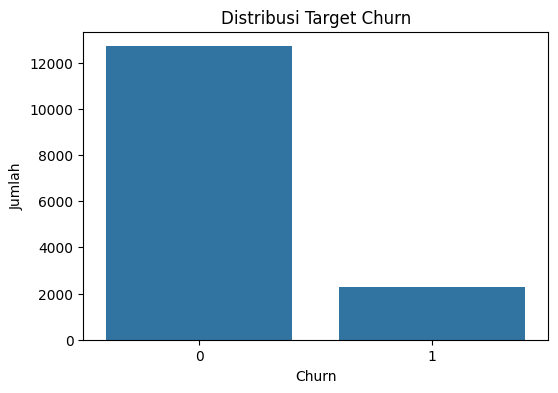

In [179]:
#Digunakan untuk menghitung jumlah pelanggan yang churn dan tidak churn
print(df["churn"].value_counts())
#Digunakan untuk menghitung proporsi atau persentase masing-masing kelas pada variabel target
print(df["churn"].value_counts(normalize=True) * 100)
#Mengatur ukuran grafik
plt.figure(figsize=(6, 4))
#Memberikan judul dan label sumbu pada grafik
sns.countplot(data=df, x="churn")
plt.title("Distribusi Target Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah")
plt.show()

Berdasarkan hasil analisis distribusi variabel target, diketahui bahwa terdapat 12.702 pelanggan yang tidak churn (kelas 0) atau sebesar 84,68%, sedangkan pelanggan yang churn (kelas 1) berjumlah 2.298 data atau sebesar 15,32%.

Visualisasi distribusi target menunjukkan bahwa dataset berada dalam kondisi **imbalanced dataset**, yaitu jumlah data pada kelas tidak churn jauh lebih banyak dibandingkan kelas churn. Ketidakseimbangan kelas ini berpotensi menyebabkan model lebih cenderung memprediksi kelas mayoritas dibandingkan kelas minoritas.

Oleh karena itu, pada tahap evaluasi model tidak hanya digunakan metrik accuracy, tetapi juga precision, recall, dan F1-score agar kemampuan model dalam mendeteksi pelanggan churn dapat dievaluasi secara lebih komprehensif.


## Heatmap Korelasi Fitur Numerik

Tahap ini dilakukan untuk melihat hubungan antar fitur numerik dalam dataset. Korelasi digunakan untuk mengetahui apakah terdapat hubungan positif atau negatif antar variabel, termasuk hubungan fitur numerik dengan variabel target `churn`.

Berdasarkan heatmap korelasi, sebagian besar fitur numerik memiliki hubungan korelasi yang relatif rendah satu sama lain. Namun terdapat beberapa fitur yang memiliki hubungan cukup terlihat dengan variabel target `churn`, seperti `satisfaction_score`, `total_spent`, dan `support_tickets`.

Fitur `satisfaction_score` terlihat memiliki korelasi negatif terhadap churn, yang berarti semakin rendah tingkat kepuasan pelanggan maka kemungkinan pelanggan untuk churn cenderung meningkat. Fitur `total_spent` juga memiliki korelasi negatif terhadap churn, sedangkan `support_tickets` memiliki korelasi positif terhadap churn. Hal ini menunjukkan bahwa pelanggan dengan banyak tiket bantuan atau komplain cenderung memiliki risiko churn lebih tinggi.

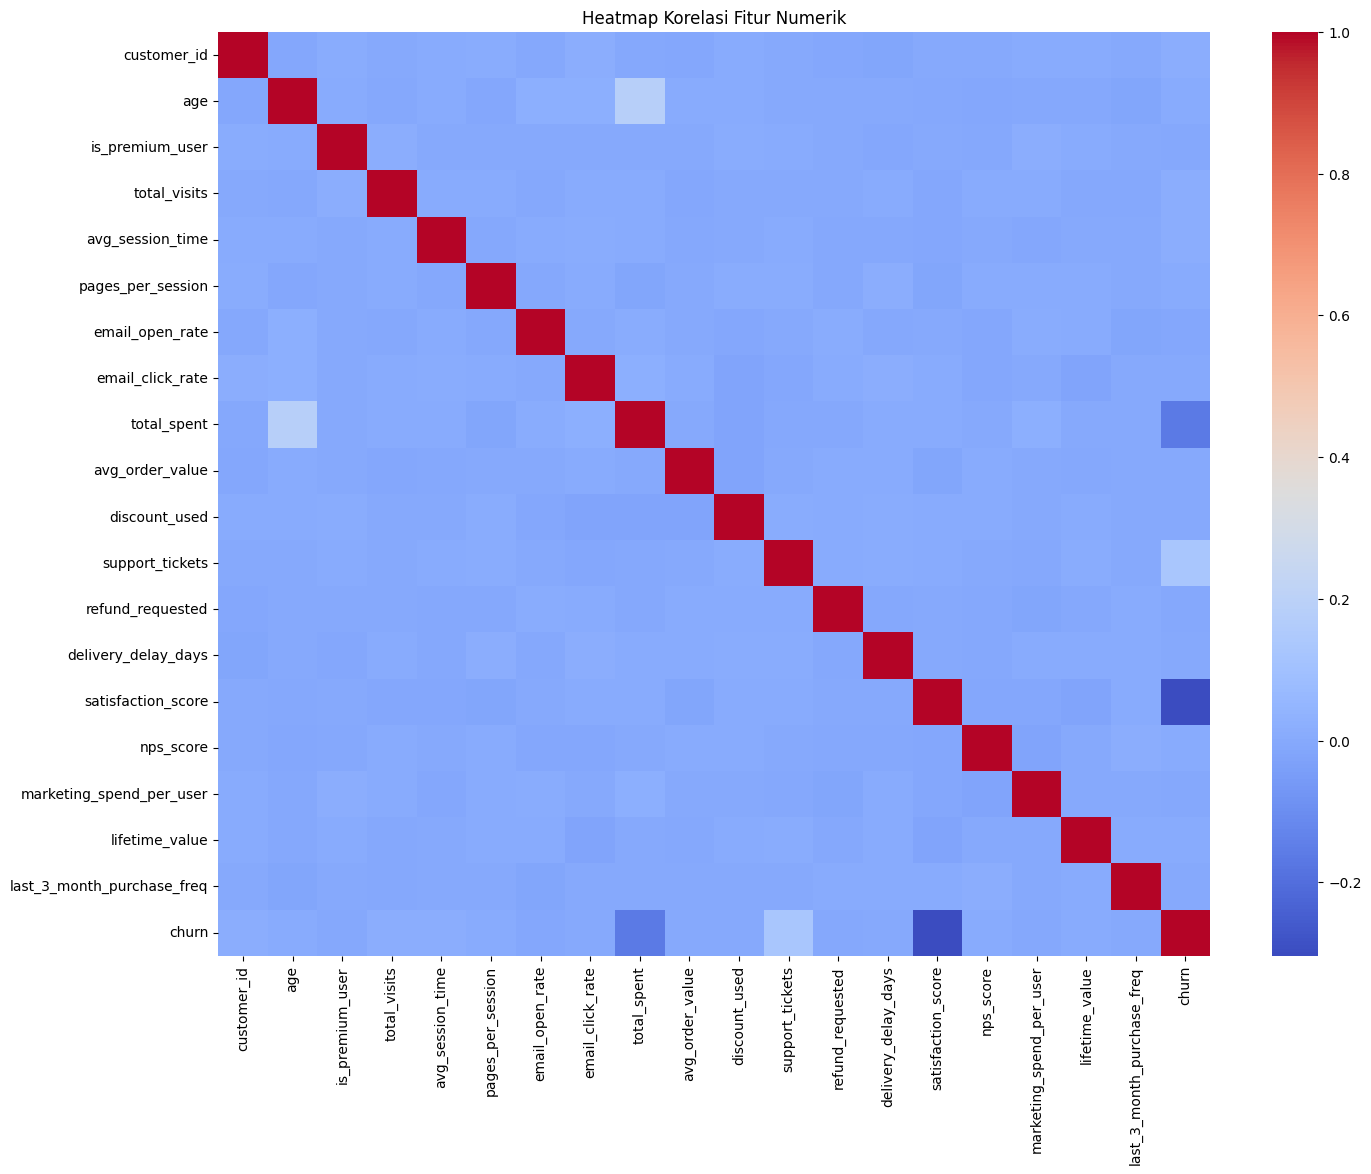

In [180]:
# 7. HEATMAP KORELASI NUMERIK
#Mengambil hanya kolom numerik dari dataset, yaitu kolom bertipe int64 dan float64
numeric_df = df.select_dtypes(include=["int64", "float64"])
#Mengatur ukuran heatmap agar lebih besar dan mudah dibaca
plt.figure(figsize=(16, 12))
#Membuat heatmap dari nilai korelasi antar fitur numerik. cmap="coolwarm" digunakan untuk membedakan korelasi positif dan negatif berdasarkan warna
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

## Analisis Korelasi Fitur terhadap Churn

Tahap ini dilakukan untuk mengetahui tingkat hubungan antara setiap fitur numerik dengan variabel target `churn`. Analisis korelasi digunakan untuk mengidentifikasi fitur-fitur yang berpotensi memiliki pengaruh terhadap keputusan pelanggan untuk tetap menggunakan layanan atau melakukan churn.

Berdasarkan hasil analisis korelasi terhadap variabel target, fitur yang memiliki korelasi positif tertinggi terhadap churn adalah `support_tickets` sebesar 0,1279. Hal ini menunjukkan bahwa pelanggan yang lebih sering menghubungi layanan bantuan memiliki kecenderungan lebih tinggi untuk melakukan churn.

Sementara itu, fitur yang memiliki korelasi negatif paling kuat adalah `satisfaction_score` sebesar -0,3036, diikuti oleh `total_spent` sebesar -0,1633. Hasil ini menunjukkan bahwa tingkat kepuasan pelanggan dan total pengeluaran pelanggan memiliki hubungan yang berlawanan dengan churn, dimana semakin tinggi kepuasan dan pengeluaran pelanggan maka kemungkinan pelanggan untuk berhenti menggunakan layanan menjadi lebih rendah.

Secara umum, tidak terdapat korelasi yang sangat kuat antar fitur terhadap variabel target. Oleh karena itu, diperlukan algoritma machine learning untuk mempelajari pola hubungan yang lebih kompleks dibandingkan analisis korelasi sederhana.

In [181]:
#Korelasi fitur terhadap churn
#Menghitung korelasi Pearson antar seluruh fitur numerik
corr_churn = numeric_df.corr()["churn"].sort_values(ascending=False)
corr_churn

,churn
churn,1.000000
support_tickets,0.127910
total_visits,0.013212
customer_id,0.012208
avg_session_time,0.012198
lifetime_value,0.006250
pages_per_session,0.005871
nps_score,0.005749
age,0.004506
delivery_delay_days,0.001603


## Visualisasi Korelasi Fitur terhadap Churn

Untuk mempermudah interpretasi hasil korelasi, dilakukan visualisasi dalam bentuk diagram batang. Grafik ini menunjukkan tingkat hubungan masing-masing fitur numerik terhadap variabel target churn, baik hubungan positif maupun negatif.

Berdasarkan grafik korelasi, fitur `satisfaction_score` memiliki korelasi negatif paling kuat terhadap churn dengan nilai sekitar -0,304. Hal ini menunjukkan bahwa pelanggan dengan tingkat kepuasan yang tinggi cenderung memiliki kemungkinan churn yang lebih rendah.

Selain itu, fitur `total_spent` juga menunjukkan korelasi negatif terhadap churn. Pelanggan yang memiliki total pengeluaran lebih besar cenderung lebih loyal terhadap layanan yang digunakan.

Di sisi lain, fitur `support_tickets` memiliki korelasi positif tertinggi terhadap churn. Hal ini mengindikasikan bahwa semakin banyak tiket bantuan atau keluhan yang dibuat pelanggan, semakin tinggi kemungkinan pelanggan tersebut melakukan churn.

Meskipun nilai korelasi yang diperoleh tidak terlalu besar, hasil ini memberikan indikasi awal mengenai fitur-fitur yang berpotensi berpengaruh terhadap churn dan dapat dimanfaatkan lebih lanjut dalam proses pemodelan machine learning.

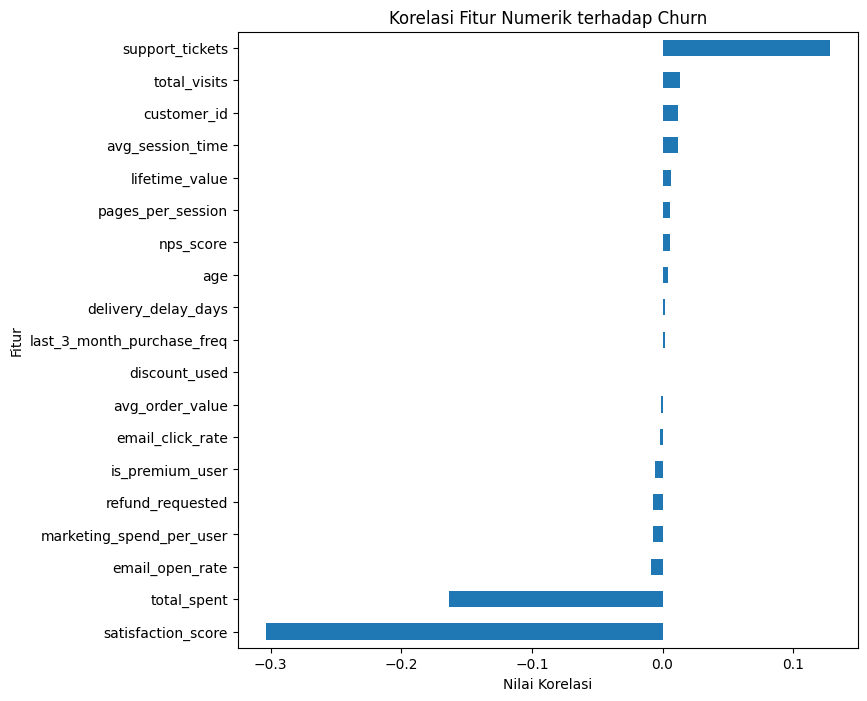

In [182]:
#BARPLOT KORELASI FITUR TERHADAP CHURN
#Menghapus korelasi churn terhadap dirinya sendiri
corr_churn_sorted = corr_churn.drop("churn").sort_values()
#Membuat ukuran grafik
plt.figure(figsize=(8, 8))
#Membuat diagram batang horizontal
corr_churn_sorted.plot(kind="barh")
plt.title("Korelasi Fitur Numerik terhadap Churn")
plt.xlabel("Nilai Korelasi")
plt.ylabel("Fitur")
plt.show()

## Direct Modeling

Pada tahap ini dilakukan pemodelan awal (baseline model) menggunakan data mentah tanpa proses preprocessing lanjutan dan tanpa hyperparameter tuning. Tujuan tahap ini adalah memperoleh performa dasar dari masing-masing algoritma machine learning sehingga dapat dibandingkan dengan hasil setelah dilakukan preprocessing dan optimasi model.

In [183]:
#IMPORT MACHINE LEARNING
#Digunakan untuk membagi dataset menjadi data latih (training set) dan data uji (testing set)
from sklearn.model_selection import train_test_split
#Digunakan untuk membangun model klasifikasi berbasis regresi logistik
from sklearn.linear_model import LogisticRegression
#Digunakan untuk membangun model ensemble berbasis kumpulan decision tree
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.preprocessing import LabelEncoder

### Menyalin Dataset

Dataset asli disalin ke dalam DataFrame baru agar proses transformasi dan encoding pada tahap direct modeling tidak mengubah data asli yang digunakan pada tahap berikutnya.

In [184]:
# COPY DATAFRAME

df_direct = df.copy()

### Penanganan Missing Value

Pada tahap direct modeling, missing value ditangani menggunakan metode sederhana agar seluruh data dapat digunakan oleh algoritma machine learning. Untuk fitur numerik digunakan nilai median, sedangkan untuk fitur kategorikal digunakan nilai modus (kategori yang paling sering muncul).

In [185]:
# HANDLE MISSING VALUE SEDERHANA


#Mengambil kolom numerik
num_cols = df_direct.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df_direct[col] = df_direct[col].fillna(df_direct[col].median())

#Mengambil kolom kategorikal
cat_cols = df_direct.select_dtypes(include="object").columns
#Mengganti missing value pada fitur numerik menggunakan nilai median masing-masing kolom
for col in cat_cols:
    df_direct[col] = df_direct[col].fillna(df_direct[col].mode()[0])

### Encoding Fitur Kategorikal

Sebagian besar algoritma machine learning hanya dapat memproses data numerik. Oleh karena itu, seluruh fitur kategorikal dikonversi menjadi representasi numerik menggunakan Label Encoding.

In [186]:
# ENCODING SEMUA KOLOM KATEGORIKAL
#Menyimpan encoder
le_dict = {}
#Melakukan Label Encoding
for col in cat_cols:
    le = LabelEncoder()
    df_direct[col] = le.fit_transform(df_direct[col])

    le_dict[col] = le

### Pembagian Data Latih dan Data Uji

Sebelum proses pelatihan model dilakukan, dataset dibagi menjadi data latih (training set) dan data uji (testing set). Data latih digunakan untuk membangun model machine learning, sedangkan data uji digunakan untuk mengevaluasi kemampuan model pada data yang belum pernah dilihat sebelumnya.

Pada penelitian ini digunakan proporsi 80% data latih dan 20% data uji. Selain itu, parameter `stratify=y` digunakan untuk menjaga distribusi kelas churn dan tidak churn tetap proporsional pada data latih maupun data uji.

In [187]:
# SPLIT X DAN y
#Memisahkan fitur dan target
#X = seluruh fitur prediktor
#y = variabel target (churn)

X = df_direct.drop("churn", axis=1)
y = df_direct["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #20% data untuk testing
    random_state=42, #hasil split selalu konsisten
    stratify=y  #menjaga proporsi churn tetap sama
)

#Menampilkan ukuran data
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (12000, 29)
X_test : (3000, 29)


Berdasarkan proses pembagian data, diperoleh 12.000 data latih dan 3.000 data uji. Jumlah fitur yang digunakan sebagai prediktor adalah 29 fitur setelah memisahkan variabel target churn. Pembagian data menggunakan teknik stratified sampling sehingga proporsi kelas churn dan tidak churn tetap terjaga pada data latih maupun data uji.

### Model 1: Logistic Regression

Logistic Regression digunakan sebagai model baseline pertama untuk melakukan klasifikasi churn pelanggan. Algoritma ini memodelkan probabilitas suatu pelanggan termasuk ke dalam kelas churn atau tidak churn berdasarkan kombinasi fitur yang dimiliki.

In [188]:
# MODEL 1 - LOGISTIC REGRESSION
#Membuat model Logistic Regression
#Digunakan untuk meningkatkan jumlah iterasi agar proses optimasi model dapat mencapai konvergensi
logreg = LogisticRegression(max_iter=1000)

#Melatih model menggunakan data latih
logreg.fit(X_train, y_train)

#Menghasilkan prediksi pada data uji
y_pred_logreg = logreg.predict(X_test)

### Evaluasi Model Logistic Regression

Model Logistic Regression dievaluasi menggunakan beberapa metrik klasifikasi yaitu Accuracy, Precision, Recall, dan F1-score. Penggunaan beberapa metrik diperlukan karena dataset memiliki distribusi kelas yang tidak seimbang (imbalanced), sehingga accuracy saja tidak cukup untuk menggambarkan performa model secara menyeluruh.

In [189]:
# EVALUASI LOGISTIC REGRESSION

print("=== Logistic Regression ===")

print("Accuracy :", accuracy_score(y_test, y_pred_logreg))
print("Precision:", precision_score(y_test, y_pred_logreg))
print("Recall   :", recall_score(y_test, y_pred_logreg))
print("F1 Score :", f1_score(y_test, y_pred_logreg))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_logreg))

=== Logistic Regression ===
Accuracy : 0.8473333333333334
Precision: 0.5069444444444444
Recall   : 0.15869565217391304
F1 Score : 0.24172185430463577

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.97      0.92      2540
           1       0.51      0.16      0.24       460

    accuracy                           0.85      3000
   macro avg       0.69      0.57      0.58      3000
weighted avg       0.81      0.85      0.81      3000



Berdasarkan hasil evaluasi, model Logistic Regression memperoleh accuracy sebesar 84,73%. Namun, karena dataset memiliki distribusi kelas yang tidak seimbang, evaluasi tidak hanya berfokus pada accuracy tetapi juga precision, recall, dan F1-score.

Model menghasilkan precision sebesar 50,69%, yang menunjukkan bahwa sekitar setengah dari pelanggan yang diprediksi churn memang benar-benar churn. Akan tetapi, nilai recall hanya sebesar 15,87%, yang berarti sebagian besar pelanggan yang sebenarnya churn gagal terdeteksi oleh model.

Nilai F1-score sebesar 24,17% menunjukkan bahwa keseimbangan antara precision dan recall masih rendah. Hal ini mengindikasikan bahwa Logistic Regression pada data mentah (tanpa preprocessing dan tuning) belum mampu mengidentifikasi pelanggan churn secara optimal.

### Model 2: Random Forest

Random Forest merupakan algoritma ensemble yang bekerja dengan menggabungkan banyak decision tree untuk menghasilkan prediksi yang lebih stabil dan akurat. Algoritma ini mampu menangani hubungan non-linear antar fitur dan relatif tahan terhadap noise serta outlier pada data.

In [138]:
# MODEL 2 - RANDOM FOREST
#Membuat model Random Forest
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

### Evaluasi Model Random Forest

Model Random Forest dievaluasi menggunakan accuracy, precision, recall, F1-score, dan classification report untuk mengetahui kemampuan model dalam mengklasifikasikan pelanggan churn dan tidak churn.

In [139]:
# =========================
# EVALUASI RANDOM FOREST
# =========================
print("=== Random Forest ===")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy : 0.8553333333333333
Precision: 0.5419354838709678
Recall   : 0.3652173913043478
F1 Score : 0.43636363636363634

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.94      0.92      2540
           1       0.54      0.37      0.44       460

    accuracy                           0.86      3000
   macro avg       0.72      0.65      0.68      3000
weighted avg       0.84      0.86      0.84      3000



Berdasarkan hasil evaluasi, model Random Forest memperoleh accuracy sebesar 85,53%, lebih tinggi dibandingkan Logistic Regression yang memperoleh accuracy sebesar 84,73%.

Selain itu, nilai precision Random Forest mencapai 54,19%, recall sebesar 36,52%, dan F1-score sebesar 43,64%. Hasil ini menunjukkan bahwa Random Forest memiliki kemampuan yang lebih baik dalam mendeteksi pelanggan churn dibandingkan Logistic Regression.

Pada kelas churn (kelas 1), nilai recall meningkat dari 15,87% pada Logistic Regression menjadi 36,52% pada Random Forest. Hal ini menunjukkan bahwa Random Forest mampu mengidentifikasi lebih banyak pelanggan yang berpotensi churn.

Secara keseluruhan, Random Forest memberikan performa yang lebih baik karena mampu menangkap pola hubungan yang lebih kompleks pada data pelanggan dibandingkan model linear seperti Logistic Regression.

### Model 3: Voting Classifier

Voting Classifier merupakan metode ensemble yang menggabungkan beberapa algoritma machine learning untuk menghasilkan prediksi akhir. Pada penelitian ini digunakan kombinasi Logistic Regression, K-Nearest Neighbor (KNN), dan Random Forest. Prediksi akhir ditentukan berdasarkan mayoritas suara (hard voting) dari ketiga model tersebut.

In [140]:
# MODEL 3 - VOTING CLASSIFIER
#Membuat Voting Classifier
voting_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('knn', KNeighborsClassifier()),
        ('rf', RandomForestClassifier(random_state=42))
    ],
    voting='hard'
)

voting_model.fit(X_train, y_train)

y_pred_vote = voting_model.predict(X_test)

### Evaluasi Model Voting Classifier

Voting Classifier dievaluasi menggunakan accuracy, precision, recall, dan F1-score untuk mengetahui efektivitas kombinasi beberapa algoritma dalam memprediksi churn pelanggan.

In [141]:
# EVALUASI VOTING CLASSIFIER
print("=== Voting Classifier ===")

print("Accuracy :", accuracy_score(y_test, y_pred_vote))
print("Precision:", precision_score(y_test, y_pred_vote))
print("Recall   :", recall_score(y_test, y_pred_vote))
print("F1 Score :", f1_score(y_test, y_pred_vote))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_vote))

=== Voting Classifier ===
Accuracy : 0.8466666666666667
Precision: 0.5
Recall   : 0.1108695652173913
F1 Score : 0.18149466192170818

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.98      0.92      2540
           1       0.50      0.11      0.18       460

    accuracy                           0.85      3000
   macro avg       0.68      0.55      0.55      3000
weighted avg       0.80      0.85      0.80      3000



Berdasarkan hasil evaluasi, Voting Classifier memperoleh accuracy sebesar 84,67%, precision sebesar 50,00%, recall sebesar 11,09%, dan F1-score sebesar 18,15%.

Meskipun accuracy yang diperoleh relatif tinggi, kemampuan model dalam mendeteksi pelanggan churn masih rendah. Hal ini terlihat dari nilai recall yang hanya mencapai 11,09%, yang menunjukkan bahwa sebagian besar pelanggan churn gagal teridentifikasi oleh model.

Hasil ini mengindikasikan bahwa kombinasi Logistic Regression, KNN, dan Random Forest menggunakan metode hard voting belum mampu meningkatkan performa klasifikasi churn dibandingkan penggunaan Random Forest secara individu.

>Kesimpulan sementara:

Random Forest terbaik pada direct modeling, karena dataset imbalance, kita jangan cuma lihat accuracy. Recall & F1-score class churn (1) lebih penting. Random Forest paling bagus mendeteksi pelanggan churn.

### Perbandingan Model Direct Modeling

Berdasarkan hasil evaluasi, Random Forest memberikan performa terbaik pada tahap direct modeling dengan nilai accuracy sebesar 85,53%, recall sebesar 36,52%, dan F1-score sebesar 43,64%. Oleh karena itu, Random Forest dipilih sebagai model baseline terbaik sebelum dilakukan preprocessing dan hyperparameter tuning.

## Feature Importance Random Forest

Tahap ini dilakukan untuk mengetahui fitur-fitur yang paling berpengaruh dalam proses prediksi churn pelanggan. Analisis feature importance menggunakan model Random Forest karena model ini mampu memberikan nilai kontribusi setiap fitur terhadap hasil prediksi.

##Preprocessing

Pada tahap ini dilakukan preprocessing data agar dataset siap digunakan pada proses pemodelan. Library `SimpleImputer`, `StandardScaler`, `OneHotEncoder`, `ColumnTransformer`, dan `Pipeline` digunakan untuk menangani nilai kosong, melakukan scaling pada fitur numerik, encoding pada fitur kategorikal, serta menggabungkan seluruh proses transformasi ke dalam satu pipeline.

Dataset kemudian disalin ke dalam variabel `df_prep` agar proses preprocessing tidak mengubah data asli. Setelah itu, beberapa fitur yang dianggap tidak relevan dihapus, yaitu `customer_id`, `signup_date`, dan `last_purchase_date`. Kolom `customer_id` dihapus karena hanya berfungsi sebagai identitas unik pelanggan dan tidak memiliki pola prediktif langsung terhadap churn. Sementara itu, `signup_date` dan `last_purchase_date` dihapus karena berupa data tanggal yang tidak digunakan secara langsung dalam model.

Selanjutnya, dataset dipisahkan menjadi fitur prediktor (`X`) dan variabel target (`y`). Variabel `X` berisi seluruh fitur selain `churn`, sedangkan variabel `y` berisi kolom `churn` sebagai target prediksi.

In [142]:

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [143]:
pip install imbalanced-learn

In [144]:
# DATA PREPROCESSING

df_prep = df.copy()

In [145]:
# DROP FITUR TIDAK RELEVAN

drop_cols = [
    "customer_id",
    "signup_date",
    "last_purchase_date"
]

df_prep = df_prep.drop(columns=drop_cols)

In [146]:
print("Missing Value:")
print(df_prep.isnull().sum())


Missing Value:
gender                         738
age                           1200
country                          0
city                             0
acquisition_channel              0
device_type                      0
subscription_type                0
is_premium_user                  0
total_visits                     0
avg_session_time                 0
pages_per_session                0
email_open_rate                  0
email_click_rate                 0
total_spent                   1050
avg_order_value                  0
discount_used                    0
coupon_code                   6133
support_tickets                  0
refund_requested                 0
delivery_delay_days              0
payment_method                   0
satisfaction_score             702
nps_score                        0
marketing_spend_per_user         0
lifetime_value                   0
last_3_month_purchase_freq       0
churn                            0
dtype: int64


Berdasarkan hasil pengecekan missing value, terdapat beberapa kolom yang memiliki nilai kosong, yaitu `gender`, `age`, `total_spent`, `coupon_code`, dan `satisfaction_score`.

Kolom dengan missing value terbesar adalah `coupon_code` sebanyak 6.133 data. Hal ini masih wajar karena tidak semua pelanggan menggunakan kode kupon saat melakukan transaksi. Selain itu, terdapat missing value pada `age` sebanyak 1.200 data, `total_spent` sebanyak 1.050 data, `gender` sebanyak 738 data, dan `satisfaction_score` sebanyak 702 data.

Missing value tersebut tidak dihapus agar jumlah data tetap terjaga. Nilai kosong akan ditangani menggunakan `SimpleImputer` pada pipeline preprocessing. Untuk fitur numerik digunakan strategi median, sedangkan untuk fitur kategorikal digunakan strategi most frequent.

In [147]:
# CEK DUPLICATE

duplicate = df_prep.duplicated().sum()

print("Jumlah data duplikat:", duplicate)

if duplicate > 0:
    df_prep = df_prep.drop_duplicates()
    print("Jumlah data setelah menghapus duplikat:", df_prep.shape[0])
else:
    print("Tidak ditemukan data duplikat.")

Jumlah data duplikat: 0
Tidak ditemukan data duplikat.


In [148]:
# CEK OUTLIER DENGAN IQR

numeric_cols = df_prep.select_dtypes(
    include=["int64", "float64"]
).columns.drop("churn")

outlier_summary = {}

for col in numeric_cols:

    Q1 = df_prep[col].quantile(0.25)
    Q3 = df_prep[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_summary[col] = (
        ((df_prep[col] < lower) |
         (df_prep[col] > upper)).sum()
    )

outlier_df = (
    pd.DataFrame({
        "Feature": outlier_summary.keys(),
        "Jumlah Outlier": outlier_summary.values()
    })
    .sort_values(
        by="Jumlah Outlier",
        ascending=False
    )
)

outlier_df

,Feature,Jumlah Outlier
11,refund_requested,2215
13,satisfaction_score,753
12,delivery_delay_days,184
0,age,89
10,support_tickets,79
7,total_spent,78
16,lifetime_value,56
8,avg_order_value,54
3,avg_session_time,45
2,total_visits,39


In [149]:
selected_features = [
    "total_spent",
    "satisfaction_score",
    "support_tickets",
    "last_3_month_purchase_freq",
    "lifetime_value",
    "avg_session_time",
    "pages_per_session",
    "total_visits",
    "email_open_rate",
    "email_click_rate"
]

X = df_prep[selected_features]
y = df_prep["churn"]

In [150]:
# KOLOM NUMERIK DAN KATEGORIKAL

num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

print("Numerik:", num_features)
print("\nKategorikal:", cat_features)

Numerik: Index(['total_spent', 'satisfaction_score', 'support_tickets',
       'last_3_month_purchase_freq', 'lifetime_value', 'avg_session_time',
       'pages_per_session', 'total_visits', 'email_open_rate',
       'email_click_rate'],
      dtype='object')

Kategorikal: Index([], dtype='object')


In [151]:
# PIPELINE NUMERIK

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [152]:
# PIPELINE KATEGORIKAL

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

##Membagi data latih dan data uji

Kode ini membagi dataset menjadi data latih dan data uji.

test_size=0.2 berarti 20% data digunakan sebagai data uji, sedangkan 80% digunakan sebagai data latih.

random_state=42 digunakan agar hasil pembagian data tetap sama setiap kali kode dijalankan.

stratify=y digunakan agar proporsi kelas churn dan tidak churn tetap seimbang pada data latih dan data uji.

In [153]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nDistribusi y_train sebelum SMOTE:")
print(y_train.value_counts())

X_train: (12000, 10)
X_test : (3000, 10)

Distribusi y_train sebelum SMOTE:
churn
0    10162
1     1838
Name: count, dtype: int64


##Membuat pipeline untuk fitur numerik

Pipeline ini digunakan untuk memproses fitur numerik.

SimpleImputer(strategy="median") digunakan untuk mengisi nilai kosong pada fitur numerik menggunakan nilai median.

StandardScaler() digunakan untuk melakukan standarisasi fitur numerik agar memiliki skala yang seimbang. Ini penting terutama untuk model seperti Logistic Regression dan KNN yang sensitif terhadap skala data.

In [154]:
# PIPELINE NUMERIK

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

##Menggabungkan preprocessing numerik dan kategorikal

Kode ini digunakan untuk menggabungkan dua proses preprocessing dalam satu objek.

Bagian "num" menerapkan numeric_transformer pada fitur numerik.

Dengan ColumnTransformer, setiap jenis fitur diproses sesuai kebutuhannya masing-masing sebelum masuk ke model machine learning.

In [155]:
# COLUMN TRANSFORMER

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features)
    ]
)

##Membuat pipeline Logistic Regression



In [156]:
# MODEL 1 - LOGISTIC REGRESSION + PREPROCESSING + SMOTE

pipe_logreg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_logreg.fit(X_train, y_train)

y_pred_logreg_prep = pipe_logreg.predict(X_test)

print("=== Logistic Regression + Preprocessing + SMOTE ===")
print("Accuracy :", accuracy_score(y_test, y_pred_logreg_prep))
print("Precision:", precision_score(y_test, y_pred_logreg_prep))
print("Recall   :", recall_score(y_test, y_pred_logreg_prep))
print("F1 Score :", f1_score(y_test, y_pred_logreg_prep))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_logreg_prep))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_logreg_prep))

=== Logistic Regression + Preprocessing + SMOTE ===
Accuracy : 0.7566666666666667
Precision: 0.35668789808917195
Recall   : 0.7304347826086957
F1 Score : 0.4793152639087018

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.76      0.84      2540
           1       0.36      0.73      0.48       460

    accuracy                           0.76      3000
   macro avg       0.65      0.75      0.66      3000
weighted avg       0.85      0.76      0.79      3000


Confusion Matrix:

[[1934  606]
 [ 124  336]]


## Random Forest

In [157]:
# MODEL 2 - RANDOM FOREST + PREPROCESSING + SMOTE

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

pipe_rf.fit(X_train, y_train)

y_pred_rf_prep = pipe_rf.predict(X_test)

print("=== Random Forest + Preprocessing + SMOTE ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf_prep))
print("Precision:", precision_score(y_test, y_pred_rf_prep))
print("Recall   :", recall_score(y_test, y_pred_rf_prep))
print("F1 Score :", f1_score(y_test, y_pred_rf_prep))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf_prep))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf_prep))

=== Random Forest + Preprocessing + SMOTE ===
Accuracy : 0.8593333333333333
Precision: 0.5269121813031161
Recall   : 0.808695652173913
F1 Score : 0.6380789022298456

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2540
           1       0.53      0.81      0.64       460

    accuracy                           0.86      3000
   macro avg       0.74      0.84      0.78      3000
weighted avg       0.89      0.86      0.87      3000


Confusion Matrix:

[[2206  334]
 [  88  372]]


##Evaluasi Voting Classifier dengan preprocessing


In [158]:
# MODEL 3 - VOTING CLASSIFIER + PREPROCESSING + SMOTE

voting_clf = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000)),
        ("knn", KNeighborsClassifier()),
        ("rf", RandomForestClassifier(random_state=42))
    ],
    voting="hard"
)

pipe_vote = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", voting_clf)
])

pipe_vote.fit(X_train, y_train)

y_pred_vote_prep = pipe_vote.predict(X_test)

print("=== Voting Classifier + Preprocessing + SMOTE ===")
print("Accuracy :", accuracy_score(y_test, y_pred_vote_prep))
print("Precision:", precision_score(y_test, y_pred_vote_prep))
print("Recall   :", recall_score(y_test, y_pred_vote_prep))
print("F1 Score :", f1_score(y_test, y_pred_vote_prep))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_vote_prep))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_vote_prep))

=== Voting Classifier + Preprocessing + SMOTE ===
Accuracy : 0.8296666666666667
Precision: 0.46800501882057716
Recall   : 0.8108695652173913
F1 Score : 0.5934765314240255

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.83      0.89      2540
           1       0.47      0.81      0.59       460

    accuracy                           0.83      3000
   macro avg       0.71      0.82      0.74      3000
weighted avg       0.88      0.83      0.85      3000


Confusion Matrix:

[[2116  424]
 [  87  373]]


##Feature Importance + Hyperparameter Tuning

In [159]:
# FEATURE IMPORTANCE RANDOM FOREST

rf_model = pipe_rf.named_steps["model"]

importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,satisfaction_score,0.319547
0,total_spent,0.267010
2,support_tickets,0.155552
7,total_visits,0.038775
5,avg_session_time,0.037826
9,email_click_rate,0.036971
4,lifetime_value,0.036850
6,pages_per_session,0.036283
8,email_open_rate,0.035831
3,last_3_month_purchase_freq,0.035356


### Visualisasi Feature Importance

Untuk mempermudah interpretasi hasil feature importance, dilakukan visualisasi dalam bentuk diagram batang. Grafik ini menunjukkan 15 fitur yang memiliki kontribusi terbesar terhadap prediksi churn berdasarkan model Random Forest.

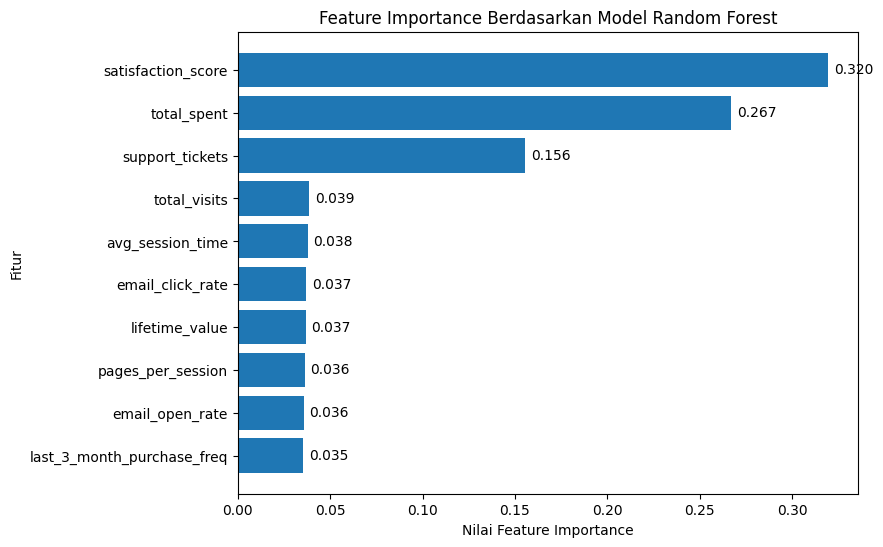

In [160]:
plt.figure(figsize=(8,6))

bars = plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Nilai Feature Importance")
plt.ylabel("Fitur")
plt.title("Feature Importance Berdasarkan Model Random Forest")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center"
    )

plt.show()

Gambar di atas menunjukkan tingkat kepentingan masing-masing fitur dalam proses prediksi churn berdasarkan model Random Forest. Semakin besar nilai feature importance, semakin besar kontribusi fitur tersebut terhadap keputusan model. Berdasarkan hasil yang diperoleh, satisfaction_score merupakan fitur yang paling berpengaruh dengan nilai importance sebesar 0,3195, diikuti oleh total_spent sebesar 0,2670 dan support_tickets sebesar 0,1556. Sementara itu, fitur lainnya memiliki kontribusi yang relatif lebih kecil namun tetap dipertahankan karena masih memberikan informasi yang relevan dalam proses klasifikasi pelanggan.

### Hyperparameter Tuning Logistic Regression

Pada tahap ini dilakukan hyperparameter tuning pada model Logistic Regression menggunakan RandomizedSearchCV. Tujuannya adalah mencari kombinasi parameter terbaik agar performa model meningkat dibandingkan model Logistic Regression sebelum tuning.

In [161]:
# HYPERPARAMETER TUNING LOGISTIC REGRESSION

from sklearn.model_selection import RandomizedSearchCV

pipe_logreg_tuning = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

param_logreg = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"],
    "model__class_weight": [None, "balanced"]
}

random_logreg = RandomizedSearchCV(
    estimator=pipe_logreg_tuning,
    param_distributions=param_logreg,
    n_iter=8,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_logreg.fit(X_train, y_train)

print("Best Params:", random_logreg.best_params_)
print("Best Score :", random_logreg.best_score_)

Best Params: {'model__solver': 'liblinear', 'model__class_weight': None, 'model__C': 0.1}
Best Score : 0.4867394045328451


## Evaluasi Logistic Regression Tuning

In [162]:
# EVALUASI LOGISTIC REGRESSION TUNING

best_logreg = random_logreg.best_estimator_

y_pred_logreg_tuned = best_logreg.predict(X_test)

print("=== Logistic Regression + Preprocessing + SMOTE + Tuning ===")
print("Accuracy :", accuracy_score(y_test, y_pred_logreg_tuned))
print("Precision:", precision_score(y_test, y_pred_logreg_tuned))
print("Recall   :", recall_score(y_test, y_pred_logreg_tuned))
print("F1 Score :", f1_score(y_test, y_pred_logreg_tuned))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_logreg_tuned))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_logreg_tuned))

=== Logistic Regression + Preprocessing + SMOTE + Tuning ===
Accuracy : 0.756
Precision: 0.3559322033898305
Recall   : 0.7304347826086957
F1 Score : 0.47863247863247865

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.76      0.84      2540
           1       0.36      0.73      0.48       460

    accuracy                           0.76      3000
   macro avg       0.65      0.75      0.66      3000
weighted avg       0.85      0.76      0.79      3000


Confusion Matrix:

[[1932  608]
 [ 124  336]]


## Hyperparameter Tuning Random Forest

In [163]:
# HYPERPARAMETER TUNING RANDOM FOREST

pipe_rf_tuning = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

param_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

random_rf = RandomizedSearchCV(
    estimator=pipe_rf_tuning,
    param_distributions=param_rf,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)

print("Best Params:", random_rf.best_params_)
print("Best Score :", random_rf.best_score_)

Best Params: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10}
Best Score : 0.6531291100751141


## Evaluasi Random Forest Tuning

In [164]:
# EVALUASI RANDOM FOREST TUNING

best_rf = random_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

print("=== Random Forest + Preprocessing + SMOTE + Tuning ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall   :", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score :", f1_score(y_test, y_pred_rf_tuned))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf_tuned))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf_tuned))

=== Random Forest + Preprocessing + SMOTE + Tuning ===
Accuracy : 0.856
Precision: 0.5159453302961275
Recall   : 0.9847826086956522
F1 Score : 0.6771300448430493

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.83      0.91      2540
           1       0.52      0.98      0.68       460

    accuracy                           0.86      3000
   macro avg       0.76      0.91      0.79      3000
weighted avg       0.92      0.86      0.87      3000


Confusion Matrix:

[[2115  425]
 [   7  453]]


## Hyperparameter Tuning Voting Classifier

In [165]:
# HYPERPARAMETER TUNING VOTING CLASSIFIER

voting_soft = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000)),
        ("knn", KNeighborsClassifier()),
        ("rf", RandomForestClassifier(random_state=42))
    ],
    voting="soft"
)

pipe_vote_tuning = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", voting_soft)
])

param_vote = {
    "model__lr__C": [0.01, 0.1, 1, 10],
    "model__lr__class_weight": [None, "balanced"],
    "model__knn__n_neighbors": [3, 5, 7],
    "model__rf__n_estimators": [100, 200],
    "model__rf__max_depth": [10, 20, None],
    "model__rf__class_weight": [None, "balanced"]
}

random_vote = RandomizedSearchCV(
    estimator=pipe_vote_tuning,
    param_distributions=param_vote,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_vote.fit(X_train, y_train)

print("Best Params:", random_vote.best_params_)
print("Best Score :", random_vote.best_score_)

Best Params: {'model__rf__n_estimators': 200, 'model__rf__max_depth': 10, 'model__rf__class_weight': None, 'model__lr__class_weight': 'balanced', 'model__lr__C': 1, 'model__knn__n_neighbors': 5}
Best Score : 0.6084913392231539


## Evaluasi Voting Classifier Tuning

In [166]:
# EVALUASI VOTING CLASSIFIER TUNING

best_vote = random_vote.best_estimator_

y_pred_vote_tuned = best_vote.predict(X_test)

print("=== Voting Classifier + Preprocessing + SMOTE + Tuning ===")
print("Accuracy :", accuracy_score(y_test, y_pred_vote_tuned))
print("Precision:", precision_score(y_test, y_pred_vote_tuned))
print("Recall   :", recall_score(y_test, y_pred_vote_tuned))
print("F1 Score :", f1_score(y_test, y_pred_vote_tuned))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_vote_tuned))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_vote_tuned))

=== Voting Classifier + Preprocessing + SMOTE + Tuning ===
Accuracy : 0.849
Precision: 0.5045278137128072
Recall   : 0.8478260869565217
F1 Score : 0.6326034063260341

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.85      0.90      2540
           1       0.50      0.85      0.63       460

    accuracy                           0.85      3000
   macro avg       0.74      0.85      0.77      3000
weighted avg       0.90      0.85      0.86      3000


Confusion Matrix:

[[2157  383]
 [  70  390]]


In [167]:
import joblib

joblib.dump(
    best_rf,
    "/content/drive/MyDrive/BENGKOD_MEGAN FPJ/UAS_BENGKOD/best1_rf_sales_marketing.pkl"
)

print("Model terbaik berhasil disimpan.")

Model terbaik berhasil disimpan.


In [168]:
# Colab
import sklearn
print(sklearn.__version__)


1.6.1
